In [1]:
import torch
import math
import numpy as np
import nugget  # Main NUGGET package for neutrino detector optimization
import matplotlib.pyplot as plt
import importlib
import pickle
import os
from nflows.distributions.normal import ConditionalDiagonalNormal, StandardNormal
from nflows.transforms.nonlinearities import PiecewiseRationalQuadraticCDF
from nflows.flows.base import Flow
from nflows.transforms.base import CompositeTransform, Transform
from nflows.transforms.autoregressive import MaskedPiecewiseRationalQuadraticAutoregressiveTransform, MaskedAffineAutoregressiveTransform

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
57.4/(1-0.924)

755.2631578947372

In [2]:
importlib.reload(nugget.surrogates.LightSabre)
device = None
light_yield_patd_surrogate = nugget.surrogates.LightSabre.LightSabrePATD(
            device=device,
            use_poisson=True, 
            num_track_points=2000, 
            domain_size=2500, 
            use_max_energy_dist=True, 
            use_perpendicular_distance_only=True,
            ).light_yield_surrogate
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(device=device, event_type='signal', domain_size=2500, E_min=1e2, E_max=1e8, energy_dist='log_uniform', find_exact_intersection=False, random_position_along_ray=True)

Number of photons: 180


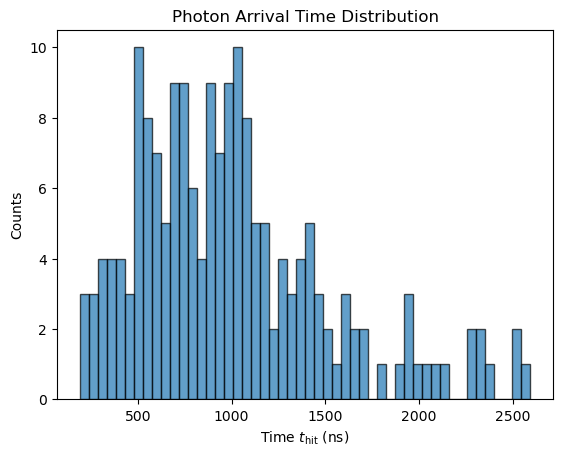

residual times min: 189.14 ns
Photon arrival times max: 2405.28076171875 ns


In [14]:
ly = 0
while ly < 100:
    signal_event = signal_sampler.sample_events(1)  # Generate one signal event with physics parameters
    coordinate = signal_sampler.sample_detector_points(1)  # Sample a detector position
    patd_dict = light_yield_patd_surrogate(opt_point=coordinate, event_params=signal_event[0])
    ly = patd_dict['num_photons']
print(f"Number of photons: {patd_dict['num_photons']}")
plt.hist(patd_dict['residual_times'].cpu().numpy(), bins=50, alpha=0.7, edgecolor='black')
plt.title('Photon Arrival Time Distribution')
plt.xlabel(r'Time $t_{\mathrm{hit}}$ (ns)')
plt.ylabel('Counts')
plt.show()
print(f"residual times min: {torch.min(patd_dict['residual_times']):.2f} ns")
print(f"Photon arrival times max: {max(patd_dict['hit_times']) - min(patd_dict['hit_times'])} ns")

In [3]:
num_samples  = 100
signal_events = []
coordinates = []
for i in range(num_samples):    
    ly = 0
    while ly < 100:
        signal_event = signal_sampler.sample_events(1)  # Generate one signal event with physics parameters
        test_coordinates = signal_sampler.sample_detector_points(1)  # Sample a detector position
        patd_dicts = light_yield_patd_surrogate(opt_point=test_coordinates, event_params=signal_event[0])
        
        # for i, patd_dict in enumerate(patd_dicts):    
        #     coordinate = test_coordinates[i]
        #     ly = patd_dict['num_photons']
        coordinate = test_coordinates
        ly = patd_dicts['num_photons']
        
    # print(ly)
    signal_events.append(signal_event)
    coordinates.append(coordinate.squeeze(0))


In [4]:
def create_event_features(event_params, coordinate, num_hits, t_geom_min = None, d_beam=None):
    energy = torch.log10(event_params['energy']).squeeze()/8
    x = coordinate[0]/1250 # Scale x position
    y = coordinate[1]/1250 # Scale y position
    z = coordinate[2]/1250  # Scale z position
    v_x = event_params['position'][0][0]/1250
    v_y = event_params['position'][0][1]/1250
    v_z = event_params['position'][0][2]/1250
    d_x = event_params['direction'][0]
    d_y = event_params['direction'][1]
    d_z = event_params['direction'][2]
    vert_dist = torch.sqrt((x-v_x)**2 + (y-v_y)**2 + (z-v_z)**2)
    # get angle between direction vector and vector from vertex to coordinate
    dir_vector = torch.tensor([d_x, d_y, d_z])
    vert_vector = torch.tensor([x-v_x, y-v_y, z-v_z])
    cos_angle = torch.dot(dir_vector, vert_vector) / (torch.norm(dir_vector) * torch.norm(vert_vector) + 1e-8)
    
    # dx = v_x - x
    # dy = v_y - y
    # dz = v_z - z
    # distance = torch.sqrt(dx**2 + dy**2 + dz**2)
    # dx = dx/distance
    # dy = dy/distance
    # dz = dz/distance
   
    # distance = torch.log10(distance)/math.log10(2500)
    log_hits = torch.log10(torch.tensor(num_hits, dtype=torch.float32))/4.0
    feature_list = [
                    energy, 
                    x, 
                    y, 
                    z, 
                    v_x, 
                    v_y, 
                    v_z, 
                    d_x, 
                    d_y, 
                    d_z,
                    vert_dist,
                    cos_angle,
                    # log_hits
                    ]
    if t_geom_min is not None:
        feature_list.append(t_geom_min/1e5)
    features = torch.stack(feature_list).unsqueeze(0)
    features = features.repeat(int(num_hits), 1)
    # if t_geom_min is not None: # add each hit's geometric time as a feature
    #     # t_geom_min_feature = torch.full((int(num_hits), 1), t_geom_min/1e3)  
    #     features = torch.cat([features, t_geom_min.unsqueeze(1)/1e3], dim=1)
    if d_beam is not None:
        features = torch.cat([features, d_beam.unsqueeze(1)/1250], dim=1)
    return features

In [5]:
def sample_detector_features(event_params, min_hits=10, output_patd_dict=False, coordinate=None):
    if coordinate is None:
        while True:
            coordinate = signal_sampler.sample_detector_points(1).squeeze(0)
            patd_dict = light_yield_patd_surrogate(opt_point=coordinate, event_params=event_params, get_patd_probs=True)
            num_hits = patd_dict['num_photons']
            if num_hits >= min_hits:
                break
    else:
        patd_dict = light_yield_patd_surrogate(opt_point=coordinate, event_params=event_params, get_patd_probs=True)
        num_hits = patd_dict['num_photons']
    features = create_event_features(event_params, coordinate, num_hits, t_geom_min=patd_dict['t_geom_min'], d_beam=patd_dict['d_geom'])
    # print(f"Geometric time min: {patd_dict['t_geom_min']} ns")
    # print(f'Number of hits: {num_hits}')
    # print(patd_dict['t_geom_min'])
    # features = create_event_features(event_params, coordinate, num_hits, t_geom_min=patd_dict['hit_times'].min())
    # hit_times = patd_dict['hit_times'].unsqueeze(1) 
    # print(patd_dict['vertex_times'])
    # hit_times = patd_dict['hit_times'].unsqueeze(1) - min(patd_dict['hit_times']) + 1e-3
    hit_times = patd_dict['hit_times'].unsqueeze(1)
    if output_patd_dict:
        return features, hit_times, patd_dict
    else:
        return features, hit_times

In [42]:
class LogTransform(Transform):
    """Log transform for photon arrival times."""
    def __init__(self):
        # initialize super
        super().__init__()
        self.scale_fac = 3

    def forward(self, x, context=None):
        # x > 0
        y = torch.log10(x) / self.scale_fac
        # y = log10(x)/4 => dy/dx = 1 / (4 * ln(10) * x)
        # log|det J| = sum_i [ -log(x_i) - log(4 * ln(10)) ]
        log_scale = math.log(self.scale_fac * math.log(10.0))
        log_det = -torch.log(x).sum(dim=-1) - x.shape[-1] * log_scale
        return y, log_det

    def inverse(self, y, context=None):
        x = 10 ** (y * self.scale_fac)
        # dx/dy = self.scale_fac * ln(10) * x
        # log|det J| = sum_i [ log(x_i) + log(self.scale_fac * ln(10)) ]
        log_scale = math.log(self.scale_fac * math.log(10.0))
        log_det = torch.log(x).sum(dim=-1) + y.shape[-1] * log_scale
        return x, log_det

class min_geometric_time_transform(Transform):
    """Shift transform to subtract geometric time from photon arrival times."""
    def forward(self, x, context):
        # context should contain the geometric time min for each hit
        t_geom_min = context[:, -2].unsqueeze(1)
        y = (x - t_geom_min) / 1e5
        # log-det of a shift is 0; scaling contributes constant Jacobian.
        log_det = x.new_full((x.shape[0],), -math.log(1e5) * x.shape[-1])
        return y, log_det

    def inverse(self, y, context):
        t_geom_min = context[:, -2].unsqueeze(1)
        # Inverse of (x - t)/1e5 is x = y*1e5 + t (not (y+t)*1e5).
        x = y * 1e5 + t_geom_min
        log_det = y.new_full((y.shape[0],), math.log(1e5) * y.shape[-1])
        return x, log_det

class MinGeomLogTransform(Transform):
    """Combine geometric-time shift/scale with signed log10 scaling in one transform."""
    def __init__(self, scale_fac=3):
        super().__init__()
        self.scale_fac = scale_fac

    def forward(self, x, context):
        t_geom_min = context[:, -2].unsqueeze(1)*1e5
        shifted_scaled = (x - t_geom_min) 
        y = torch.where(
            shifted_scaled < 0,
            -torch.log10(-shifted_scaled),
            torch.log10(shifted_scaled),
        ) / self.scale_fac

        log_scale = math.log(self.scale_fac * math.log(10.0))
        log_det = (
            - torch.log(torch.abs(shifted_scaled)).sum(dim=-1)
            - x.shape[-1] * log_scale
        )
        return y, log_det

    def inverse(self, y, context):
        t_geom_min = context[:, -2].unsqueeze(1)*1e5
        shifted_scaled = torch.where(
            y < 0,
            -10 ** (-y * self.scale_fac),
            10 ** (y * self.scale_fac),
        )
        x = shifted_scaled + t_geom_min

        log_scale = math.log(self.scale_fac * math.log(10.0))
        log_det = (
            # math.log(1e5) * y.shape[-1]
            + torch.log(torch.abs(shifted_scaled)).sum(dim=-1)
            + y.shape[-1] * log_scale
        )
        return x, log_det


def make_autoregressive_rqs():
    return MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
        features=1,
        hidden_features=800,
        context_features=14,
        num_bins=8,
        tails="linear",
        tail_bound=4,
        activation=torch.nn.SiLU()
    )



def make_mixing_transform():
    # Piecewise rational spline to add mixing/nonlinearity between AR blocks.
    return PiecewiseRationalQuadraticCDF(shape=[1], tail_bound=1, tails='linear', num_bins=10)


# context_encoder = torch.nn.Sequential(
#     torch.nn.Linear(12, 64),
#     torch.nn.SiLU(),
#     torch.nn.Linear(64, 64),
#     torch.nn.SiLU(),
#     torch.nn.Linear(64, 2),
# )

# base_dist = ConditionalDiagonalNormal(
#     shape=[1],
#     context_encoder=context_encoder,
# )
base_dist = StandardNormal(shape=[1]) 

transforms = [
    MinGeomLogTransform(scale_fac=5),
    # min_geometric_time_transform(),
    # LogTransform()
    ]
num_layers = 3
for _ in range(num_layers):
    transforms.append(make_autoregressive_rqs())
    # transforms.append(make_mixing_transform())

transform = CompositeTransform(transforms)
flow = Flow(transform, base_dist)
# optimizer = torch.optim.Adam(flow.parameters(), lr=0.1e-4)

# Point 6: optimization stabilization knobs
learning_rate = 0.1e-4
weight_decay = 1e-6



num_iterations = 6000
optimizer = torch.optim.Adam(flow.parameters(), 
                             lr=learning_rate, 
                             weight_decay=weight_decay
                             )
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_iterations,
    eta_min=0.1e-5,
)

In [40]:
features_batch, sample_times_raw, patd_dict = sample_detector_features(signal_event[0], min_hits=1, coordinate=None, output_patd_dict=True)
print(f"Hit times range: {sample_times_raw.min().item():.6f} to {sample_times_raw.max().item():.6f}")
print(f"Hit times has NaN: {torch.isnan(sample_times_raw).any()}")
print(f"Features has NaN: {torch.isnan(features_batch).any()}")
# print(f"Features range: {features_batch.min().item():.6f} to {features_batch.max().item():.6f}")
# print(torch.unique(features_batch))
# print(torch.unique(sample_times_raw))
print(features_batch[:,-2][0]*1e5)

Hit times range: 6457.637207 to 6457.637207
Hit times has NaN: False
Features has NaN: False
tensor(4464.1016)


In [43]:
torch.autograd.set_detect_anomaly(False)
num_iterations = 4000
all_test_samples = []
all_test_probs = []
max_batch_size = 300
events_per_batch = [30, 20, 10, 1]
charge_mins = [1,10,100,1000]
num_events = 5

for iteration in range(num_iterations):
    optimizer.zero_grad()
    collected_log_probs = []
    collected_true_log_probs = []
    event_mean_log_probs = []
    collected_hits = 0
    iter_idx = iteration // (num_iterations // len(charge_mins))
    min_charge = charge_mins[iter_idx]
    # num_events = events_per_batch[iter_idx]
    # while collected_hits < max_batch_size:
    for _ in range(num_events):
        #randomly select a signal event and coordinate from the pre-sampled list
        random_idx = torch.randint(0, len(signal_events), (1,)).item()
        signal_event = signal_events[random_idx]
        features_batch, sample_times_raw, patd_dict = sample_detector_features(signal_event[0], min_hits=min_charge, coordinate=None, output_patd_dict=True)
        # randomly subsample hits
        # if features_batch.shape[0] > 10:
        indices = torch.randperm(features_batch.shape[0])
        features_batch = features_batch[indices]
        sample_times_raw = sample_times_raw[indices]

        log_probs = flow.log_prob(sample_times_raw, context=features_batch)
        collected_log_probs.append(log_probs)
        # event_mean_log_probs.append(log_probs.mean())
        collected_hits += log_probs.shape[0]
        collected_true_log_probs.append(patd_dict['patd_probs'][indices].log())
    print(f"Collected hits: {collected_hits}")

    raw_true_log_probs = -torch.cat(collected_true_log_probs, dim=0)
    finite_true_log_probs = raw_true_log_probs[torch.isfinite(raw_true_log_probs)]
    loss = -torch.cat(collected_log_probs, dim=0).mean()

    # Filter out non-finite values before averaging to avoid NaN in logs.
    if finite_true_log_probs.numel() > 0:
        true_total_log_prob = finite_true_log_probs.mean()
    else:
        true_total_log_prob = torch.tensor(0.0, device=loss.device)
    # per_event_loss = -torch.stack(event_mean_log_probs).mean()
    # loss = per_event_loss if objective_mode == "per_event" else per_hit_loss

    loss.backward()
    optimizer.step()
    scheduler.step()
   
    if (iteration % 100 in range(len(charge_mins))) or (iteration == num_iterations - 1):
        print(f"Iteration {iteration+1}/{num_iterations}, Loss: {loss.item():.4f}, True Total Log Prob: {true_total_log_prob.item():.4f}")

Collected hits: 76
Iteration 1/4000, Loss: 11.8188, True Total Log Prob: 6.9759
Collected hits: 329
Iteration 2/4000, Loss: 10.3546, True Total Log Prob: 6.8684
Collected hits: 166
Iteration 3/4000, Loss: 10.3417, True Total Log Prob: 7.0089
Collected hits: 21
Iteration 4/4000, Loss: 10.9613, True Total Log Prob: 7.2399
Collected hits: 118
Collected hits: 92
Collected hits: 134
Collected hits: 257
Collected hits: 35


KeyboardInterrupt: 

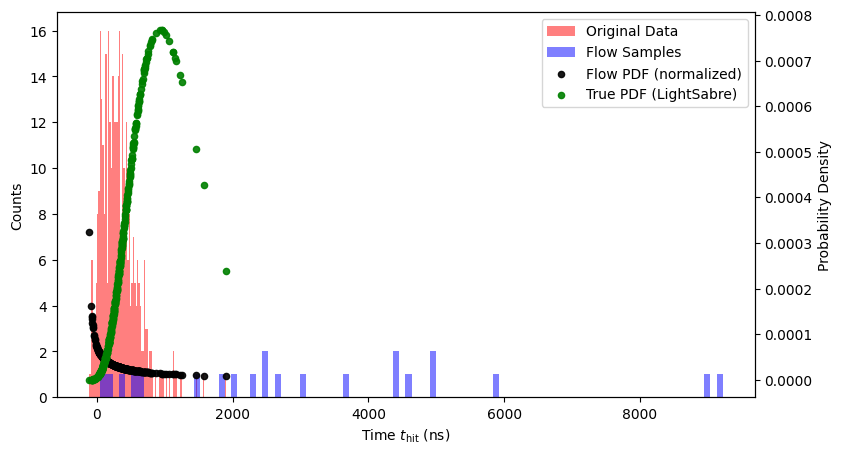

Charge of original data: 364, Charge of flow samples: 22
Min of original data: -117.3345, Min of flow samples: 53.7893


In [44]:
random_idx = torch.randint(0, len(signal_events), (1,)).item()
signal_event = signal_events[random_idx]
features_batch, sample_times_raw, patd_dict = sample_detector_features(
    signal_event[0], min_hits=10, output_patd_dict=True, coordinate=None
)

num_obs = int(sample_times_raw.shape[0])
samples = flow.sample(
    num_samples=num_obs,
    context=features_batch[0].unsqueeze(0),
).squeeze(0)

# sigma clip samples to be within the same range as the original data
# for _ in range(2):  # iteratively remove outliers to get a better sense of the main distribution
#     samples = samples[samples > samples.mean() - 2 * samples.std()]
#     samples = samples[samples < samples.mean() + 2 * samples.std()]
samples = samples[samples > 0]
samples = samples[samples < 1e4]
sample_times_np = sample_times_raw.detach().cpu().numpy().squeeze()
samples_np = samples.detach().cpu().numpy().squeeze()

# Use identical bins for both histograms so count comparison is meaningful.
counts, bin_edges = np.histogram(sample_times_np, bins=100)
pred_counts, pred_edges = np.histogram(samples_np, bins=100)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.stairs(
    counts,
    bin_edges,
    label='Original Data',
    color='red',
    alpha=0.5,
    linewidth=1.0,
    fill=True,
)
ax1.stairs(
    pred_counts,
    pred_edges,
    label='Flow Samples',
    color='blue',
    alpha=0.5,
    linewidth=1.0,
    fill=True,
)

# Evaluate model PDF on a common domain.
test_sample_times_t = torch.linspace(
    float(sample_times_raw.min().item()),
    float(sample_times_raw.max().item()),
          
    # min(float(sample_times_raw.min().item()), float(samples.min().item())),
    # max(float(sample_times_raw.max().item()), float(samples.max().item())),
    300,
    dtype=sample_times_raw.dtype,
    device=sample_times_raw.device,
).unsqueeze(1)
# test_context = features_batch[0].unsqueeze(0).repeat(test_sample_times_t.shape[0], 1)

# probs = torch.exp(flow.log_prob(test_sample_times_t, context=test_context)).detach().cpu().numpy().squeeze()
probs = torch.exp(flow.log_prob(sample_times_raw, context=features_batch)).detach().cpu().numpy().squeeze()
# x_grid = sample_times_raw.detach().cpu().numpy().squeeze()

# Normalize the learned PDF numerically so its area over the plotted domain is 1.
# probs = np.clip(probs, a_min=0.0, a_max=None)
# area = np.trapezoid(probs, x_grid)
# probs_norm = probs / area if area > 0 else probs

# Build the true PDF from the LightSabre generation process.
# Each photon has its own geometric shift and CPandel residual distribution,
# so the comparable density on hit_time is a mixture over the sampled photons.
residual_times = patd_dict['residual_times'].detach().cpu().numpy().squeeze()
d_geom = patd_dict['d_geom'].detach().cpu().numpy().squeeze()

true_pdf = nugget.surrogates.cpandel.cpandel.pdf(
            residual_times,
            d=d_geom,
        )
# true_area = np.trapezoid(true_pdf, x_grid)
# true_pdf_norm = true_pdf / true_area if true_area > 0 else true_pdf

ax2.scatter(
    sample_times_raw.detach().cpu().numpy().squeeze(),
    probs,
    color='k',
    label='Flow PDF (normalized)',
    alpha=0.9,
    s=20,
    zorder=3,
)
ax2.scatter(
    sample_times_raw.detach().cpu().numpy().squeeze(),
    true_pdf,
    color='green',
    label='True PDF (LightSabre)',
    alpha=0.9,
    s=20,
    zorder=3,
)

ax1.set_xlabel(r'Time $t_{\mathrm{hit}}$ (ns)')
ax1.set_ylabel('Counts')
ax2.set_ylabel('Probability Density')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

print(f"Charge of original data: {counts.sum()}, Charge of flow samples: {pred_counts.sum()}")
print(f"Min of original data: {sample_times_raw.min().item():.4f}, Min of flow samples: {samples.min().item():.4f}")